guide = https://youtu.be/6EJaHBJhwDs?list=PLKnIA16_Rmvboy8bmDCjwNHgTaYH2puK7

# SETUP DATA 

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, Dataset

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split

%matplotlib inline 


torch.manual_seed(42)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [33]:
df = pd.DataFrame(pd.read_csv(r'datasets\fashion-mnist_train.csv'))

In [34]:
df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In [35]:
# df.scatter(x=df['pixel1'],y=df['pixel2'], hue = 'label' )
# sns.histplot(df['label'])
df['label'].value_counts()

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64

In [36]:
X = df.iloc[:,1:].values
y = df.iloc[:, 0].values

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [38]:
# scaling features 

X_train = X_train/255.0
X_test = X_test/255.0

# DATASET , DATALOADER 


In [39]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]


In [40]:
train_dataset = CustomDataset(X_train, y_train)

# print(len(train_dataset))
# print(train_dataset[0])

In [41]:
test_dataset = CustomDataset(X_test, y_test)

# print(len(test_dataset))
# print(test_dataset[0])

## CREATING TRAIN n TEST LODER 

In [42]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

# CREATING NN

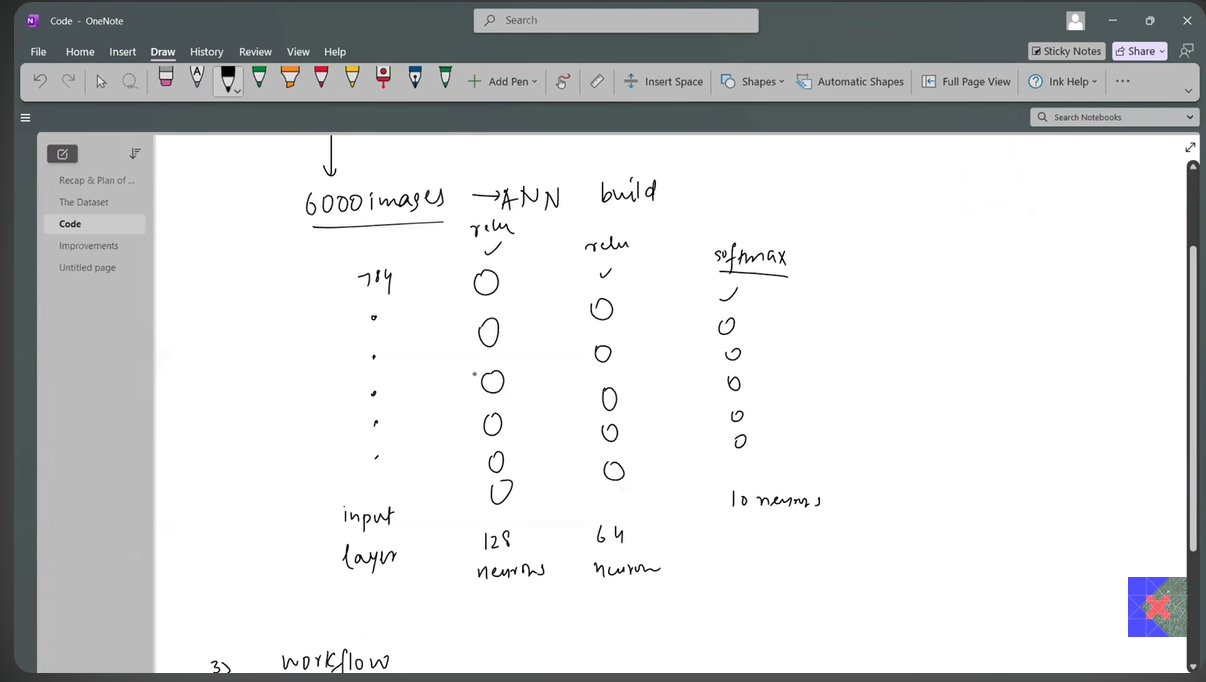

In [43]:
class simpleNN(nn.Module) : 
    def __init__(self, feature_num):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(feature_num, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)

        )


    def forward(self, input_dataset):
        return self.model(input_dataset)


In [44]:
# setting LR, EPOCHS 

epochs = 100
lr = 0.1

In [45]:
# model instantiate
model = simpleNN(X_train.shape[1])
model.to(device)
# loss function 
criterion = nn.CrossEntropyLoss()


# optimizer 
optimizer = optim.SGD(model.parameters(), lr)

## TRAINING LOOP

In [46]:

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        output_preds = model(batch_features) 
        
        #calc loss
        loss = criterion(output_preds,batch_labels)
        total_epoch_loss += loss.item()

        #backpropogation
        optimizer.zero_grad()
        loss.backward()
        
        #update grads 
        optimizer.step()
        total_epoch_loss += loss.item()
    
    avg_loss_per_epoch = total_epoch_loss/len(train_loader)
    print(f"AVG LOSS IN EPOCH {epoch}: {total_epoch_loss:.5f}")

AVG LOSS IN EPOCH 0: 676.47859
AVG LOSS IN EPOCH 1: 396.99005
AVG LOSS IN EPOCH 2: 347.29123
AVG LOSS IN EPOCH 3: 318.78946
AVG LOSS IN EPOCH 4: 301.79495
AVG LOSS IN EPOCH 5: 289.19598
AVG LOSS IN EPOCH 6: 274.94395
AVG LOSS IN EPOCH 7: 265.87757
AVG LOSS IN EPOCH 8: 257.23560
AVG LOSS IN EPOCH 9: 250.28086
AVG LOSS IN EPOCH 10: 242.98685
AVG LOSS IN EPOCH 11: 235.18380
AVG LOSS IN EPOCH 12: 230.77378
AVG LOSS IN EPOCH 13: 223.57404
AVG LOSS IN EPOCH 14: 221.36500
AVG LOSS IN EPOCH 15: 215.93730
AVG LOSS IN EPOCH 16: 210.53630
AVG LOSS IN EPOCH 17: 205.34966
AVG LOSS IN EPOCH 18: 203.39932
AVG LOSS IN EPOCH 19: 199.09375
AVG LOSS IN EPOCH 20: 194.23070
AVG LOSS IN EPOCH 21: 191.32248
AVG LOSS IN EPOCH 22: 186.57530
AVG LOSS IN EPOCH 23: 182.35960
AVG LOSS IN EPOCH 24: 180.44500
AVG LOSS IN EPOCH 25: 176.44010
AVG LOSS IN EPOCH 26: 174.31254
AVG LOSS IN EPOCH 27: 171.88660
AVG LOSS IN EPOCH 28: 169.75822
AVG LOSS IN EPOCH 29: 164.40206
AVG LOSS IN EPOCH 30: 162.37393
AVG LOSS IN EPOCH 

# EVALUATION

In [47]:
# SET MODEL TO EVAL MODE 

model.eval()



simpleNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [48]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
    print(correct/total)
                                           

0.9650208333333333


In [49]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
print(correct/total)
                                           

0.8839166666666667


# REDUCING OVERFITTING

potential options :

* more training data
* Reduce NN complexity 
* Regularisation                    -------------------- DOING
* Dropouts                          -------------------- DOING
* Data Augumentation
* Batch Normalisation               -------------------- DOING
* Early Stopping

In [50]:
class simpleNNforOverfiting(nn.Module) : 
    def __init__(self, feature_num):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(feature_num, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,10)

        )


    def forward(self, input_dataset):
        return self.model(input_dataset)


In [51]:
# setting LR, EPOCHS 
epochs = 100
lr = 0.1

In [52]:
# model instantiate
model_for_overfit = simpleNNforOverfiting(X_train.shape[1])
model_for_overfit.to(device)
# loss function 
criterion = nn.CrossEntropyLoss()


# optimizer 
optimizer = optim.SGD(model_for_overfit.parameters(), lr, weight_decay=1e-4)

## TRAINING LOOP

In [53]:

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        output_preds = model_for_overfit(batch_features) 
        
        #calc loss
        loss = criterion(output_preds,batch_labels)
        total_epoch_loss += loss.item()

        #backpropogation
        optimizer.zero_grad()
        loss.backward()
        
        #update grads 
        optimizer.step()
        total_epoch_loss += loss.item()
    
    avg_loss_per_epoch = total_epoch_loss/len(train_loader)
    print(f"AVG LOSS IN EPOCH {epoch}: {total_epoch_loss:.5f}")

AVG LOSS IN EPOCH 0: 492.99918
AVG LOSS IN EPOCH 1: 364.35935
AVG LOSS IN EPOCH 2: 333.22576
AVG LOSS IN EPOCH 3: 315.13403
AVG LOSS IN EPOCH 4: 300.13585
AVG LOSS IN EPOCH 5: 289.27092
AVG LOSS IN EPOCH 6: 281.63126
AVG LOSS IN EPOCH 7: 272.91242
AVG LOSS IN EPOCH 8: 266.69018
AVG LOSS IN EPOCH 9: 259.96654
AVG LOSS IN EPOCH 10: 254.37957
AVG LOSS IN EPOCH 11: 246.41399
AVG LOSS IN EPOCH 12: 245.00728
AVG LOSS IN EPOCH 13: 239.52118
AVG LOSS IN EPOCH 14: 234.09601
AVG LOSS IN EPOCH 15: 231.57673
AVG LOSS IN EPOCH 16: 227.67675
AVG LOSS IN EPOCH 17: 224.00285
AVG LOSS IN EPOCH 18: 221.11620
AVG LOSS IN EPOCH 19: 218.91545
AVG LOSS IN EPOCH 20: 217.91491
AVG LOSS IN EPOCH 21: 215.86264
AVG LOSS IN EPOCH 22: 209.61353
AVG LOSS IN EPOCH 23: 208.64855
AVG LOSS IN EPOCH 24: 204.58508
AVG LOSS IN EPOCH 25: 204.09607
AVG LOSS IN EPOCH 26: 202.49659
AVG LOSS IN EPOCH 27: 199.24753
AVG LOSS IN EPOCH 28: 197.12138
AVG LOSS IN EPOCH 29: 194.44631
AVG LOSS IN EPOCH 30: 192.42384
AVG LOSS IN EPOCH 

## EVALUATION

In [54]:
# SET MODEL TO EVAL MODE 

model_for_overfit.eval()



simpleNNforOverfiting(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [55]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model_for_overfit(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
    print(correct/total)
                                           

0.9411041666666666


In [56]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model_for_overfit(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
print(correct/total)
                                           

0.8768333333333334


# OPTUNA 

In [61]:
import optuna


In [59]:
class myNNforOptuna(nn.Module) :

    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer) : 
        super().__init__()

        layers = [] 

        #adding INPUT + HIDDEN LAYERS
        for i in range(num_hidden_layers) :

            layers.append(nn.Linear(input_dim, neurons_per_layer))  
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))

            input_dim = neurons_per_layer

        # ADDING OUTPUT LAYER 
        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, input):

        return self.model(input)
    

In [64]:
# OBJECTIVE FUNCTION 

def objective(trial) :

    #extract hyperparameters values for next trial from search space 
    num_hidden_layers = trial.suggest_int("num_hidden_layers", 1,5)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 8,128)

    input_dim = 784 
    output_dim = 10 


    #initialise model 
    model_optuna = myNNforOptuna(input_dim, output_dim, num_hidden_layers, neurons_per_layer)
    model_optuna.to(device)


    #intialise params n optimiser 
    lr = 0.1
    epochs = 50

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_optuna.parameters(), lr= lr, weight_decay=1e-4)


    #training loop  
    
    for epoch in range(epochs):

        for batch_features, batch_labels in train_loader:
            
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            # forward pass
            output_preds = model_optuna(batch_features) 
            
            #calc loss
            loss = criterion(output_preds,batch_labels)


            #backpropogation
            optimizer.zero_grad()
            loss.backward()
            
            #update grads 
            optimizer.step()
        

    #evaluation 
    total = 0
    correct = 0

    with torch.no_grad():

        for batch_features, batch_labels in test_loader :
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            feature_preds = model_optuna(batch_features)

            _, output_lables = torch.max(feature_preds, 1)

            total = total + batch_labels.shape[0]
            correct = correct + (output_lables == batch_labels).sum().item()
    
    
    accuracy  = correct/total
    return accuracy 

In [65]:
study = optuna.create_study(direction="maximize")

[I 2026-07-22 20:45:09,029] A new study created in memory with name: no-name-0b29ff27-354b-4c21-905a-8e452f7c3254


In [66]:
study.optimize(objective, n_trials=10)

[I 2026-07-22 20:46:08,745] Trial 0 finished with value: 0.752 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 16}. Best is trial 0 with value: 0.752.
[I 2026-07-22 20:47:41,969] Trial 1 finished with value: 0.8605 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 88}. Best is trial 1 with value: 0.8605.
[I 2026-07-22 20:48:48,966] Trial 2 finished with value: 0.8455833333333334 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 43}. Best is trial 1 with value: 0.8605.
[I 2026-07-22 20:49:56,438] Trial 3 finished with value: 0.86375 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 90}. Best is trial 3 with value: 0.86375.
[I 2026-07-22 20:51:28,423] Trial 4 finished with value: 0.8511666666666666 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 63}. Best is trial 3 with value: 0.86375.
[I 2026-07-22 20:52:55,080] Trial 5 finished with value: 0.7288333333333333 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 21